# Deep Learning Models

In this notebook, we’ll explore five deep learning architectures:

1. Basic Neural Networks (NN)
2. Convolutional Neural Networks (CNNs)
3. Autoencoders
4. Diffusion Models
5. Transformers

## 00. Linear Functions

Before diving into neural networks, let’s start with the basics: **linear functions**.

A linear function looks like this:

$$
y = mx + b
$$

* **m** is the slope (how steep the line is)
* **b** is the y-intercept (where the line crosses the y-axis)

Linear models try to draw a straight line through your data. They’re fast and easy—but they have limits.

---

### Non-linear:

Linear models only work well when your data is **linear**.
But what happens when your data is curved, clustered, or complex?

That’s when we need to **introduce non-linearity**, and that’s where neural networks—and activation functions like ReLU—come in.

In [ ]:
# %pip install tensorflow tensorflow-datasets matplotlib numpy scikit-learn 

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

# Generate sample data
np.random.seed(42)
X = 2 * np.random.rand(100, 1)
y = 4 + 3 * X + np.random.randn(100, 1)  # y = 4 + 3x + noise

# Train a linear regression model
lin_reg = LinearRegression()
lin_reg.fit(X, y)

# Predict
X_new = np.array([[0], [2]])
y_pred = lin_reg.predict(X_new)

# Plot the data and the prediction line
plt.scatter(X, y, label="Data")
plt.plot(X_new, y_pred, color="red", label=f"Model: y = {lin_reg.coef_[0][0]:.2f}x + {lin_reg.intercept_[0]:.2f}")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Simple Linear Regression")
plt.legend()
plt.grid(True)
plt.show()


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import interact, FloatSlider

# Create a range of x values
x = np.linspace(0, 2, 100)

# Interactive plotting function
def plot_linear(m=1.0, b=0.0):
    y = m * x + b
    plt.figure(figsize=(6, 4))
    plt.plot(x, y, color='red', label=f"y = {m:.1f}x + {b:.1f}")
    plt.title("Adjust the Slope (m) and Intercept (b)")
    plt.xlabel("x")
    plt.ylabel("y")
    plt.grid(True)
    plt.ylim(-2, 10)
    plt.legend()
    plt.show()

# Sliders for slope and intercept
interact(plot_linear,
         m=FloatSlider(value=1.0, min=-5.0, max=5.0, step=0.1),
         b=FloatSlider(value=0.0, min=-5.0, max=5.0, step=0.1));


## Activation Functions

So far, we've seen how a **linear equation** (like `y = mx + b`) produces a single straight line. But real-world data — like classifying images or understanding speech — isn't so neatly linear.

To make neural networks **learn nonlinear patterns**, we need something more flexible. That's where **activation functions** come in.

### What is an Activation Function?

An activation function decides **whether a neuron should "fire"** based on the input it receives. It's applied **after** the linear transformation (`wx + b`) in each neuron.

---

### Enter ReLU: Rectified Linear Unit

The most popular activation function is **ReLU**, defined as:

$ReLU(x) = \max(0, x)$

Simple but it’s powerful.

- For negative inputs, it returns **0**.
- For positive inputs, it returns **x** (unchanged).

---

### Why ReLU Helps with Nonlinear Data

- **Nonlinear decisions**: ReLU introduces **kinks** into the function, allowing networks to stitch together multiple straight lines and form curves.
- **Sparsity**: ReLU outputs 0 for negative values, which keeps the model **efficient and fast** to train.
- **Stacking** ReLU layers means your model can learn **complex, nonlinear patterns** — like classifying spirals, moons, or clothing items.

---

In short: Without ReLU (or some activation function), a neural network would just behave like one long linear equation — no matter how many layers it had.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Input range
x = np.linspace(-5, 5, 200)
relu = np.maximum(0, x)

plt.figure(figsize=(6, 4))
plt.plot(x, relu, color='orange', linewidth=2)
plt.title("ReLU Activation Function")
plt.xlabel("Input")
plt.ylabel("Output")
plt.grid(True)
plt.axhline(0, color='black', linestyle='--', linewidth=0.5)
plt.axvline(0, color='black', linestyle='--', linewidth=0.5)
plt.show()


#### What Is a Loss Function?

A **loss function** is a mathematical way to measure how far a model’s prediction is from the actual answer.

Think of it like a score:

* High loss = the model is doing poorly
* Low loss = the model is doing well

The goal of training is to **minimize this loss** by adjusting internal parameters.

---

#### Example: Mean Squared Error (MSE)

Let’s say we have a model trying to predict the number `3`, but it outputs `2.5`.

The **MSE** would be:

$$
\text{MSE} = (3 - 2.5)^2 = 0.25
$$

For multiple predictions, MSE averages the squared differences:

$$
\text{MSE} = \frac{1}{n} \sum_{i=1}^n (y_i - \hat{y}_i)^2
$$

Where:

* $y_i$ is the true value
* $\hat{y}_i$ is the predicted value

---

#### Learning

Loss functions guide how models **learn**. If we don't define a good way to measure error, the model won’t know how to improve.

For example:

* **Linear regression** uses MSE
* **Classification** often uses cross-entropy
* **Autoencoders** use MSE to compare input and output images


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# True and predicted values
y_true = np.array([3, -0.5, 2, 7])
y_pred = np.array([2.5, 0.0, 2, 8])
x = np.arange(len(y_true))

# Calculate MSE
mse = np.mean((y_true - y_pred) ** 2)

# Plot
plt.figure(figsize=(8, 5))
plt.plot(x, y_true, 'o-', label='True Values', color='blue')
plt.plot(x, y_pred, 's--', label='Predicted Values', color='orange')
for i in range(len(x)):
    plt.vlines(x[i], y_pred[i], y_true[i], color='gray', linestyle='dotted')  # error lines

plt.title(f'Mean Squared Error = {mse:.2f}')
plt.xlabel("Sample Index")
plt.ylabel("Value")
plt.legend()
plt.grid(True)
plt.show()


Putting it all together...

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import tensorflow as tf
from tensorflow.keras import layers, models
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

# Generate dataset
X, y = make_moons(n_samples=500, noise=0.2, random_state=0)
scaler = StandardScaler()
X = scaler.fit_transform(X)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

# Grid for decision boundary
xx, yy = np.meshgrid(np.linspace(-2, 2.5, 200), np.linspace(-1.5, 2, 200))
grid = np.c_[xx.ravel(), yy.ravel()]

# Build model
model = models.Sequential([
    layers.Dense(10, activation='relu', input_shape=(2,)),
    layers.Dense(10, activation='relu'),
    layers.Dense(1, activation='sigmoid')
])
model.compile(optimizer='adam', loss='binary_crossentropy')

# For animation
fig, ax = plt.subplots(figsize=(7, 5))

def update(frame):
    ax.clear()
    model.fit(X_train, y_train, epochs=5, verbose=0)  # 5 iters per frame
    Z = model.predict(grid, verbose=0)[:, 0].reshape(xx.shape)
    ax.contourf(xx, yy, Z, levels=np.linspace(0, 1, 20), cmap='coolwarm', alpha=0.6)
    ax.scatter(X[:, 0], X[:, 1], c=y, cmap='coolwarm', edgecolor='k')
    ax.set_title(f"Training Step {frame * 5}")
    ax.set_xlim(-2, 2.5)
    ax.set_ylim(-1.5, 2)

ani = FuncAnimation(fig, update, frames=20, repeat=False)
plt.close()
HTML(ani.to_jshtml())


## 01. Basic Neural Network (NN)

A neural network is a collection of neurons organized in layers. Each layer transforms the input and passes it to the next.

Main idea: Learn patterns from data by adjusting weights.

Let’s train a simple NN to classify handwritten digits (MNIST).


In [ ]:
import tensorflow as tf
from keras.datasets import mnist
import matplotlib.pyplot as plt
import numpy as np

# https://storage.googleapis.com/tensorflow/tf-keras-datasets/mnist.npz
# Load local MNIST .npz file manually
# with np.load("mnist.npz") as data:
#     trainX, trainY = data['x_train'], data['y_train']
#     testX, testY = data['x_test'], data['y_test']

# Load the dataset
(trainX, trainY), (testX, testY) = mnist.load_data()

# Normalize the images to [0, 1] range (IMPORTANT)
trainX = trainX / 255.0
testX = testX / 255.0

# Check shapes (optional)
print("Train X:", trainX.shape)
print("Test X:", testX.shape)
print("Train Y:", trainY.shape)
print("Test Y:", testY.shape)


In [ ]:
# Display example images
plt.imshow(trainX[1500], cmap='magma')
plt.title(f"Label: {trainY[1500]}")
plt.show()

In [ ]:
# Build a simple neural network
firstNeuralNetwork = tf.keras.models.Sequential([
    tf.keras.layers.Flatten(input_shape=(28,28)),
    tf.keras.layers.Dense(150, activation='relu'),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Dense(10, activation='softmax')  # <-- Add softmax for classification
])

# Compile the model
firstNeuralNetwork.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Train the model
firstNeuralNetwork.fit(trainX, trainY, epochs=5)  # 5 epochs is enough for demo

# Evaluate on test data
test_loss, test_acc = firstNeuralNetwork.evaluate(testX, testY)
print(f"\nTest Accuracy: {test_acc:.4f}")

In [ ]:
firstNeuralNetwork.summary()

## Neural Network Structure Summary

This model is a **Sequential** neural network built with Keras. It takes 28×28 pixel grayscale images (like MNIST) and passes them through the following layers:

| Layer            | Type      | Output Shape | Description |
|------------------|-----------|---------------|-------------|
| `Flatten`        | Flatten   | `(None, 784)` | Converts each 28×28 image into a 1D vector of 784 pixels |
| `Dense`          | Dense     | `(None, 150)` | Fully connected layer with 150 neurons + ReLU activation |
| `Dropout`        | Dropout   | `(None, 150)` | Randomly drops 20% of neurons during training to prevent overfitting |
| `Dense`          | Dense     | `(None, 10)`  | Final layer with 10 output neurons (one per digit class) + softmax |

### 📊 Parameter Breakdown

- **Total trainable parameters**: 119,260
- **Total parameters**: 357,782 (includes optimizer state)
- **Non-trainable parameters**: 0

> The final `Dense` layer outputs a probability distribution across the 10 digit classes (0–9). The model "chooses" the digit with the highest score.


### What’s happening in our Neural Network?

- **Trainable parameters**: The weights and biases that get updated during training
- **ReLU**: An activation function that helps the model learn nonlinear patterns
- **Dropout**: Randomly disables some neurons during training to prevent overfitting
- **Dense layer**: A fully connected layer — every neuron connects to all inputs



In [ ]:
import random
import numpy as np

# Pick a random image from the test set
idx = random.randint(0, len(testX) - 1)
sample_image = np.expand_dims(testX[idx], axis=0)  # Add batch dimension

# Predict using the trained model
prediction = firstNeuralNetwork.predict(sample_image)
predicted_label = np.argmax(prediction)

# Plot the image
plt.imshow(testX[idx], cmap='magma')
plt.title(f"True Label: {testY[idx]} | Predicted: {predicted_label}")
plt.axis('off')
plt.show()


In [ ]:
# EXERCISE 1: Confusion Matrix

# Now that you've trained your model, let's evaluate how well it performs on each digit.
# Your task: Use sklearn's ConfusionMatrixDisplay to show how well your model predicted each class.

# 1. Use your trained model to predict all labels on the test set.
# 2. Convert the predictions from probabilities to class labels (hint: use np.argmax).
# 3. Generate a confusion matrix using sklearn.
# 4. Display it using ConfusionMatrixDisplay.

# Use the help command below if you're stuck
# from sklearn.metrics import ConfusionMatrixDisplay
# ConfusionMatrixDisplay?  <-- uncomment this to get help

# TODO: Fill in the code below

# Step 1: Predict all test images
y_pred_probs = firstNeuralNetwork.predict(testX)

# Step 2: Convert to predicted class labels
y_pred_classes = ___

# Step 3: Compute the confusion matrix
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
cm = ___

# Step 4: Display the confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=np.arange(10))
disp.plot(cmap='magma', xticks_rotation=45)
plt.title("Confusion Matrix")
plt.grid(False)
plt.show()


In [ ]:
# Find all incorrect predictions
wrong_indices = np.where(y_pred_classes != testY)[0]

# Pick one
import random
idx = random.choice(wrong_indices)

# Plot the image
plt.imshow(testX[idx], cmap='gray')
plt.title("Predicted: {} | Actual: {}".format(y_pred_classes[idx], testY[idx]))
plt.axis('off')
plt.show()


## 02. CNNs - Convolutional Neural Networks

CNNs are designed to work with image data. They apply filters (kernels) that slide over the image to detect patterns like edges, corners, and textures.

Main idea: Local feature extraction using convolution.

Let’s use a pretrained CNN to classify an image!


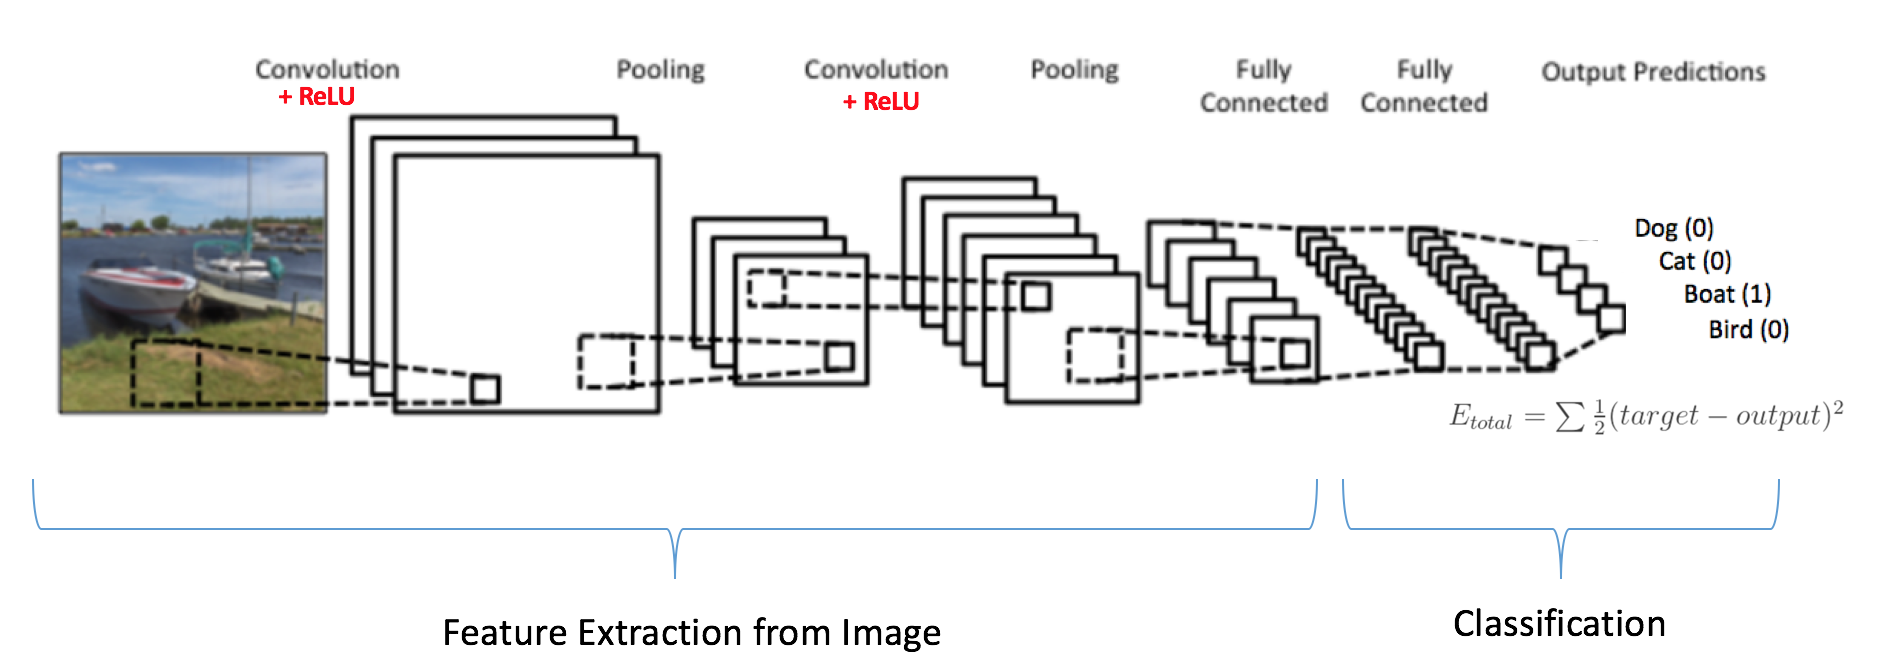

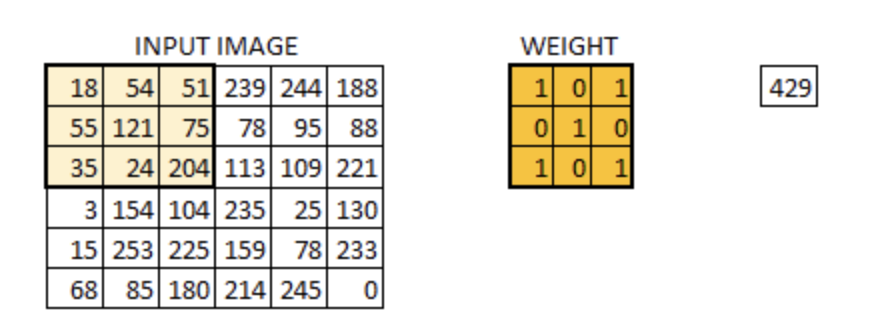

In [ ]:
import tensorflow as tf
from tensorflow.keras.datasets import fashion_mnist
import matplotlib.pyplot as plt

# Load Fashion MNIST data
(trainX, trainY), (testX, testY) = fashion_mnist.load_data()

# Normalize images to [0, 1]
trainX = trainX / 255.0
testX = testX / 255.0

# Class names for interpretation
class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']


In [ ]:
import random

# Pick a random index
idx = random.randint(0, len(trainX) - 1)

# Show the randomly selected image
plt.imshow(trainX[idx], cmap='gray')
plt.title(f"Label: {class_names[trainY[idx]]}")
plt.axis('off')
plt.show()


In [ ]:
# Build a simple CNN
model = tf.keras.models.Sequential([
    tf.keras.layers.Reshape((28, 28, 1), input_shape=(28, 28)),  # Add channel dimension
    tf.keras.layers.Conv2D(32, (3, 3), activation='relu'),       # 32 filters, 3x3 kernel
    tf.keras.layers.MaxPooling2D((2, 2)),                        # Downsample
    tf.keras.layers.Conv2D(64, (3, 3), activation='relu'),       # More filters
    tf.keras.layers.MaxPooling2D((2, 2)),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(64, activation='relu'),                # Dense layer
    tf.keras.layers.Dense(10, activation='softmax')              # Output layer
])

# Compile the CNN
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# Train the model
model.fit(trainX, trainY, epochs=5)


In [ ]:
# Pick a random image from the test set
idx = random.randint(0, len(testX) - 1)
img = testX[idx]
label = testY[idx]

# Prepare the image for prediction
img_input = np.expand_dims(img, axis=0)     # shape: (1, 28, 28)
img_input = np.reshape(img_input, (1, 28, 28, 1))  # shape: (1, 28, 28, 1) for CNN

# Predict
pred = model.predict(img_input)
predicted_label = class_names[np.argmax(pred)]

# Show image with prediction
plt.imshow(img, cmap='gray')
plt.title(f"Predicted: {predicted_label} | Actual: {class_names[label]}")
plt.axis('off')
plt.show()


In [ ]:
# Predict on all test images
y_pred_probs = model.predict(testX.reshape(-1, 28, 28, 1))  # reshape if CNN expects 4D input
y_pred_classes = np.argmax(y_pred_probs, axis=1)

# Create confusion matrix
cm = confusion_matrix(testY, y_pred_classes)

# Display it
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(cmap='magma', xticks_rotation=45)
plt.title("Confusion Matrix")
plt.grid(False)
plt.show()


## 03. Autoencoders

Autoencoders learn to compress data (encoding) and then reconstruct it (decoding). They’re useful for tasks like denoising, anomaly detection, and data compression.

Main idea: Learn a compressed representation.

We’ll build a tiny one on MNIST.


Autoencoders are neural networks trained to compress input data into a smaller representation (encoding), then reconstruct it back to its original form (decoding). When trained on clean inputs and given noisy data at test time, they learn to **denoise** — removing irrelevant or corrupted information.

We use them to:

* Learn compressed representations of data.
* Reconstruct input from noisy versions.
* Discover patterns without needing labels (unsupervised learning).

---

#### Denoising Example:

We’ll add noise to Fashion MNIST images and train an autoencoder to reconstruct the clean version.

Formally:

Let:

* $\mathbf{x}$ be the clean image
* $\tilde{\mathbf{x}} = \mathbf{x} + \text{noise}$
* $\hat{\mathbf{x}} = \text{Decoder(Encoder(}\tilde{\mathbf{x}}\text{))}$

We minimize the loss:

$$
\mathcal{L} = \| \hat{\mathbf{x}} - \mathbf{x} \|^2
$$

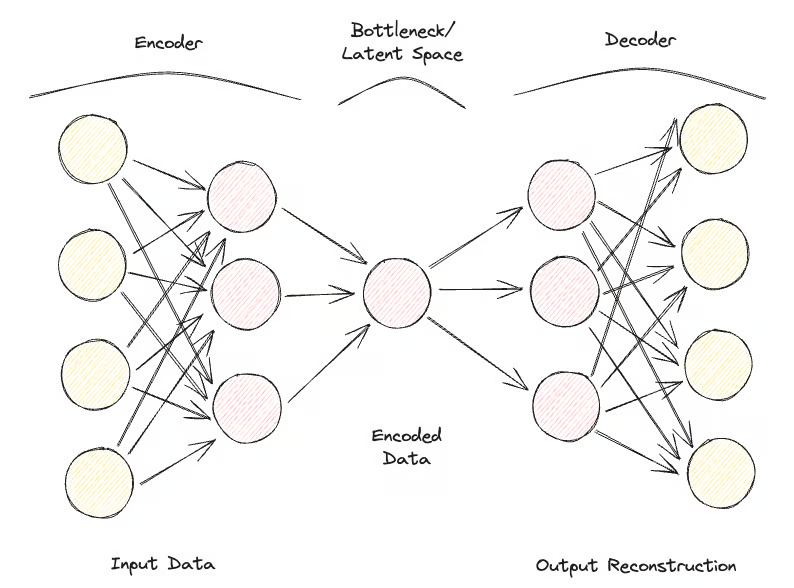

In [ ]:
# import numpy as np
# import matplotlib.pyplot as plt
# from tensorflow.keras.datasets import fashion_mnist
# from tensorflow.keras.models import Sequential
# from tensorflow.keras.layers import Dense, Flatten, Reshape
# from tensorflow.keras.optimizers import Adam

# # Load dataset
# (trainX, _), (testX, _) = fashion_mnist.load_data()
# trainX = trainX.astype('float32') / 255.
# testX = testX.astype('float32') / 255.

# Add Gaussian noise
noise_factor = 0.5
trainX_noisy = trainX + noise_factor * np.random.normal(loc=0.0, scale=1.0, size=trainX.shape) 
testX_noisy = testX + noise_factor * np.random.normal(loc=0.0, scale=1.0, size=testX.shape)

# Clip to stay within [0,1]
trainX_noisy = np.clip(trainX_noisy, 0., 1.)
testX_noisy = np.clip(testX_noisy, 0., 1.)

# Show example: clean vs noisy
plt.figure(figsize=(6, 2))
for i in range(5):
    # Original
    plt.subplot(2, 5, i+1)
    plt.imshow(trainX[i], cmap='gray')
    plt.axis('off')
    # Noisy
    plt.subplot(2, 5, i+6)
    plt.imshow(trainX_noisy[i], cmap='gray')
    plt.axis('off')
plt.suptitle("Top: Clean | Bottom: Noisy")
plt.tight_layout()
plt.show()


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Reshape
from tensorflow.keras.optimizers import Adam

input_shape = (28, 28)
flattened_dim = 784

autoencoder = Sequential([
    Flatten(input_shape=input_shape),
    Dense(128, activation='relu'),
    Dense(64, activation='relu'),
    Dense(128, activation='relu'),
    Dense(flattened_dim, activation='sigmoid'),
    Reshape(input_shape)
])

autoencoder.compile(optimizer=Adam(), loss='mse')
autoencoder.summary()


In [ ]:
history = autoencoder.fit(
    trainX_noisy, trainX,
    epochs=10,
    batch_size=256,
    shuffle=True,
    validation_data=(testX_noisy, testX)
)


In [ ]:
decoded_imgs = autoencoder.predict(testX_noisy)

# Show original, noisy, and denoised images
n = 5
plt.figure(figsize=(9, 3))
for i in range(n):
    # Noisy
    plt.subplot(3, n, i + 1)
    plt.imshow(testX_noisy[i], cmap='gray')
    plt.title("Noisy")
    plt.axis('off')

    # Clean
    plt.subplot(3, n, i + 1 + n)
    plt.imshow(testX[i], cmap='gray')
    plt.title("Clean")
    plt.axis('off')

    # Denoised
    plt.subplot(3, n, i + 1 + 2*n)
    plt.imshow(decoded_imgs[i], cmap='gray')
    plt.title("Denoised")
    plt.axis('off')
plt.tight_layout()
plt.show()


## Universal Approximation Theorem and the Evolution of Function

The **Universal Approximation Theorem (UAT)** is a foundational idea in neural networks. It states:

> A feedforward neural network with just **one hidden layer** and **a sufficient number of neurons** can approximate **any continuous function** on a compact input space, given appropriate weights and activation functions.

In other words, neural networks are not limited to a specific set of tasks — they are **universal function learners**.

This is powerful: it tells us that if we can define a task as a function (e.g., mapping input data to a prediction), a neural network *can* learn it — no matter how complex.  
The only remaining question is: *how do we train it to get there?*

### From Learning to Evolving

Just like in biology, learning involves a process of selection. In evolution, molecules that **perform useful functions** (e.g., binding a target, replicating themselves) are more likely to persist. Over time, these systems accumulate **functional information** — that is, information that supports a function.

In neural networks, the **loss function** plays the role of selection:  
- We start with random weights (random guesses).  
- We use gradient descent to adjust them, selecting the configurations that **perform better** on the task.  
- Over time, the model **accumulates structure** — it gains functional capacity.

So while UAT tells us what is possible in theory, the **training process** is what shapes the network toward *useful*, *functional* outcomes.

### Functional Information and Complexity

Biological evolution and machine learning both share a deeper principle:  
They are **search processes through a vast space of possibilities**, looking for **function**.

Recent theories in complexity science and astrobiology propose that:
> The universe favors the rise of complexity when systems are selected for function.

This mirrors what we see in trained networks:
- Structure emerges where there was none.
- Simple units combine to express sophisticated functions.
- Systems develop generalization, modularity, and even creativity.

Biology may increasingly be understood through the lens of information theory and computation

**Sources**
https://www.quantamagazine.org/why-everything-in-the-universe-turns-more-complex-20250402/
https://en.wikipedia.org/wiki/Universal_approximation_theorem
